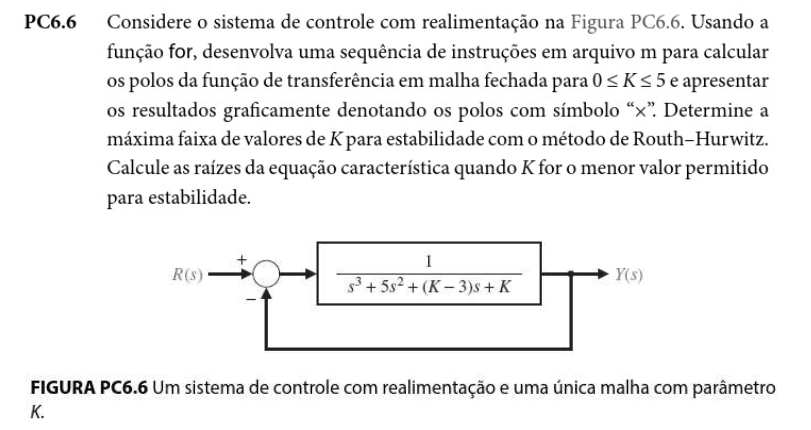

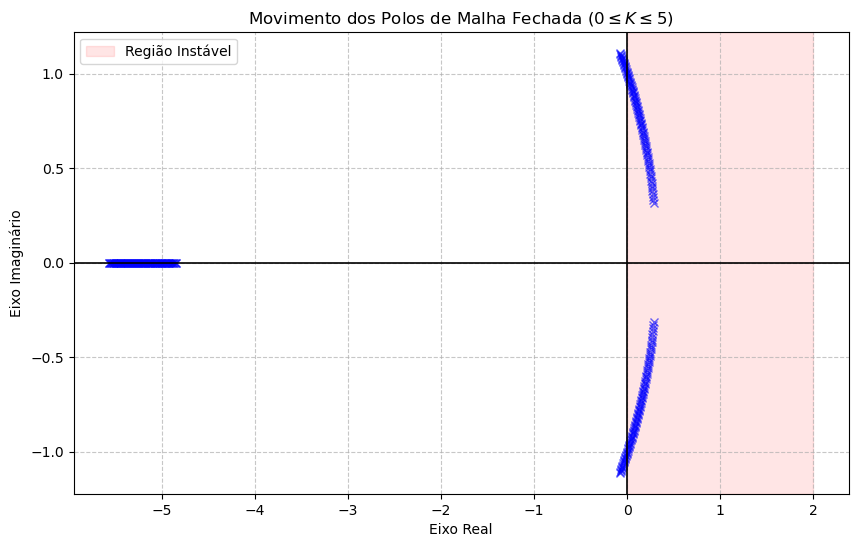


--- Análise para o limite de estabilidade (K = 4) ---
A equação característica de malha fechada é:
[1 5 1 5]

As raízes (polos) para K = 4 são:
Raiz 1: (-5+0j)
Raiz 2: 1j
Raiz 3: -1j


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import control as ct

# ---------------------------------------------------------
# PARTE 1: Gráfico dos polos para 0 <= K <= 5
# ---------------------------------------------------------

# Criando um vetor de valores para K de 0 a 5
K_vals = np.linspace(0, 5, 100)

plt.figure(figsize=(10, 6))

for K in K_vals:
    # Definindo a planta em malha aberta G(s)
    # Numerador = [1]
    # Denominador = [1, 5, K-3, K]
    num_G = [1]
    den_G = [1, 5, K-3, K]
    G = ct.tf(num_G, den_G)
    
    # Calculando o sistema em malha fechada T(s) com realimentação unitária
    T = ct.feedback(G, 1)
    
    # Extraindo os polos de malha fechada
    polos = ct.poles(T)
    
    # Plotando os polos com "x"
    # Usamos uma cor azul e um alpha menor para ver a densidade do movimento
    plt.plot(np.real(polos), np.imag(polos), 'x', color='blue', alpha=0.6)

plt.title(r'Movimento dos Polos de Malha Fechada ($0 \leq K \leq 5$)')
plt.xlabel('Eixo Real')
plt.ylabel('Eixo Imaginário')
plt.axhline(0, color='black', lw=1.2)
plt.axvline(0, color='black', lw=1.2)
plt.grid(True, linestyle='--', alpha=0.7)

# Destacando o limite de estabilidade
plt.axvspan(0, 2, color='red', alpha=0.1, label='Região Instável')
plt.legend()
plt.show()

# ---------------------------------------------------------
# PARTE 2: Polos para o menor valor estável (K = 4)
# ---------------------------------------------------------
K_limite = 4
print(f"\n--- Análise para o limite de estabilidade (K = {K_limite}) ---")

# Construindo a FT para K = 4
num_G_lim = [1]
den_G_lim = [1, 5, K_limite-3, K_limite]
G_lim = ct.tf(num_G_lim, den_G_lim)
T_lim = ct.feedback(G_lim, 1)

# Calculando as raízes
raizes_limite = ct.poles(T_lim)

print("A equação característica de malha fechada é:")
print(T_lim.den[0][0])
print("\nAs raízes (polos) para K = 4 são:")
for i, raiz in enumerate(raizes_limite):
    print(f"Raiz {i+1}: {np.round(raiz, 4)}")